# 02 — Model Development

Comparación reproducible de modelos para predecir `churn`.

## Objetivos
- Utilizar el pipeline de preprocesamiento definido en `src/`.
- Comparar Regresión Logística, Árbol de Decisión y Random Forest.
- Evaluar Accuracy, Precision, Recall, F1 y ROC-AUC.
- Seleccionar el modelo final con una regla explícita.
- Guardar el pipeline completo y las métricas.


## 1. Configuración del entorno

El notebook debe ejecutarse desde la raíz del repositorio. En Google Colab:

```python
!git clone <URL_DEL_REPOSITORIO>
%cd customer-intelligence-ml-platform
```


In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
        if (candidate / "src").exists():
            PROJECT_ROOT = candidate
            break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f"Project root: {PROJECT_ROOT}")


Project root: /workspaces/customer-intelligence-ml-platform/entregable_D3_16_repositorio_final_curso_1


## 2. Importaciones


In [2]:
import json
import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from src.data import load_customer_data
from src.features import build_preprocessing_pipeline, split_features_target
from src.models.evaluation import evaluate_binary_classifier
from src.utils import get_project_path, get_logger
logger = get_logger("notebook.model_development")


## 3. Carga y separación de datos


In [3]:
DATA_PATH = get_project_path("data", "raw", "customer_churn.csv")
df = load_customer_data(DATA_PATH)
X, y = split_features_target(df)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")
print(f"Train churn rate: {y_train.mean():.2%}")
print(f"Test churn rate: {y_test.mean():.2%}")


2026-09-30 02:26:34,397 | INFO | src.data.data_loader | Loaded customer dataset with shape (1000, 21)


Train rows: 800
Test rows: 200
Train churn rate: 24.00%
Test churn rate: 24.00%


## 4. Definición de modelos


In [4]:
models = {
    "logistic_regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "decision_tree": DecisionTreeClassifier(max_depth=6, min_samples_split=10, class_weight="balanced", random_state=42),
    "random_forest": RandomForestClassifier(n_estimators=250, max_depth=10, min_samples_split=5, class_weight="balanced", random_state=42, n_jobs=-1),
}
models


{'logistic_regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
 'decision_tree': DecisionTreeClassifier(class_weight='balanced', max_depth=6,
                        min_samples_split=10, random_state=42),
 'random_forest': RandomForestClassifier(class_weight='balanced', max_depth=10,
                        min_samples_split=5, n_estimators=250, n_jobs=-1,
                        random_state=42)}

## 5. Entrenamiento y evaluación


In [5]:
trained_pipelines = {}
results = []
for model_name, estimator in models.items():
    pipeline = Pipeline(steps=[("preprocessor", build_preprocessing_pipeline()), ("classifier", estimator)])
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    probabilities = pipeline.predict_proba(X_test)[:, 1]
    metrics = evaluate_binary_classifier(y_true=y_test, y_pred=predictions, y_proba=probabilities)
    trained_pipelines[model_name] = pipeline
    results.append({"model": model_name, **metrics})
results_df = pd.DataFrame(results).set_index("model").sort_values("roc_auc", ascending=False)
results_df


,accuracy,precision,recall,f1,roc_auc
model,,,,,
random_forest,0.730,0.448276,0.541667,0.490566,0.737664
logistic_regression,0.645,0.378947,0.750000,0.503497,0.728344
decision_tree,0.565,0.314286,0.687500,0.431373,0.596697


## 6. Comparación visual


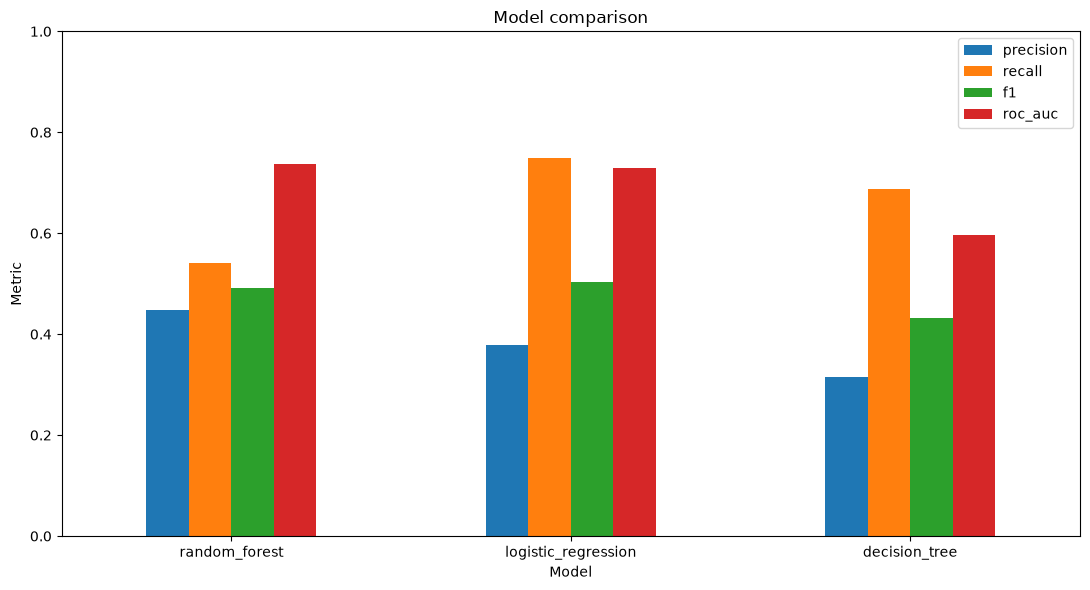

In [6]:
ax = results_df[["precision", "recall", "f1", "roc_auc"]].plot(kind="bar", figsize=(11, 6))
ax.set_title("Model comparison")
ax.set_xlabel("Model")
ax.set_ylabel("Metric")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 7. Regla de selección

Se prioriza ROC-AUC y luego F1-score. Accuracy no se usa como único criterio por el desbalance de clases.


In [7]:
selection_table = results_df.sort_values(by=["roc_auc", "f1"], ascending=False)
selected_model_name = selection_table.index[0]
selected_pipeline = trained_pipelines[selected_model_name]
print(f"Selected model: {selected_model_name}")
selection_table


Selected model: random_forest


,accuracy,precision,recall,f1,roc_auc
model,,,,,
random_forest,0.730,0.448276,0.541667,0.490566,0.737664
logistic_regression,0.645,0.378947,0.750000,0.503497,0.728344
decision_tree,0.565,0.314286,0.687500,0.431373,0.596697


## 8. Importancia de variables del Random Forest


In [8]:
rf_pipeline = trained_pipelines["random_forest"]
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = rf_pipeline.named_steps["classifier"].feature_importances_
feature_importance = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False).head(15)
feature_importance


,feature,importance
1,tenure_months,0.092806
3,total_spent,0.090394
8,marketing_score,0.073740
7,digital_usage_score,0.073051
2,monthly_fee,0.072909
0,age,0.062987
6,last_payment_delay,0.060547
23,contract_type_Mensual,0.054750
4,support_calls,0.054392
9,preferred_contact_hour,0.053005


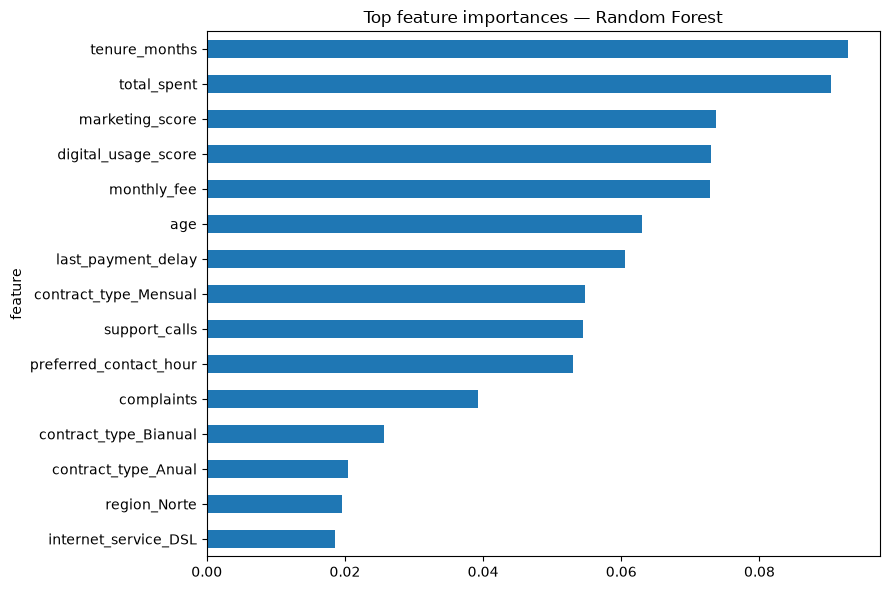

In [9]:
ax = feature_importance.sort_values("importance").plot(x="feature", y="importance", kind="barh", figsize=(9, 6), legend=False)
ax.set_title("Top feature importances — Random Forest")
plt.tight_layout()
plt.show()


## 9. Guardado del modelo y métricas


In [10]:
MODEL_PATH = get_project_path("artifacts", "models", "selected_churn_pipeline.joblib", create_parent=True)
METRICS_PATH = get_project_path("reports", "metrics", "model_comparison.json", create_parent=True)
joblib.dump(selected_pipeline, MODEL_PATH)
payload = {
    "selected_model": selected_model_name,
    "selection_rule": ["roc_auc", "f1"],
    "test_size": 0.20,
    "random_state": 42,
    "results": results_df.reset_index().to_dict(orient="records"),
}
METRICS_PATH.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"Model saved to: {MODEL_PATH}")
print(f"Metrics saved to: {METRICS_PATH}")


Model saved to: /workspaces/customer-intelligence-ml-platform/entregable_D3_16_repositorio_final_curso_1/artifacts/models/selected_churn_pipeline.joblib
Metrics saved to: /workspaces/customer-intelligence-ml-platform/entregable_D3_16_repositorio_final_curso_1/reports/metrics/model_comparison.json


## 10. Verificación del artefacto


In [11]:
loaded_pipeline = joblib.load(MODEL_PATH)
sample_predictions = loaded_pipeline.predict(X_test.head(5))
sample_probabilities = loaded_pipeline.predict_proba(X_test.head(5))[:, 1]
pd.DataFrame({"prediction": sample_predictions, "probability": sample_probabilities})


,prediction,probability
0,0,0.432468
1,0,0.217864
2,0,0.363604
3,1,0.525067
4,1,0.588257


## 11. Preguntas para discusión
1. ¿Por qué Accuracy no debe ser la única métrica?
2. ¿Qué modelo obtuvo mejor Recall?
3. ¿Qué consecuencias tendría usar un umbral distinto de 0.50?
4. ¿Qué ventajas tiene guardar todo el pipeline?
5. ¿Qué riesgo existe al seleccionar con el conjunto de prueba?


## Resultado esperado
- comparación reproducible de tres modelos;
- criterio explícito de selección;
- pipeline guardado en `artifacts/models/`;
- métricas en `reports/metrics/`.
